# Month 1 — Baseline Pipeline: Heart Disease Prediction
This notebook runs the end-to-end baseline framework for heart disease prediction using the UCI Cleveland dataset.

### Steps:
1. **Load and Clean Dataset**: Load Cleveland dataset, handle missing values (`?`), and binarize target variable (`0`: no disease, `1`: disease present).
2. **Preprocessing**: Impute and scale numerical features, impute and one-hot encode categorical features.
3. **Model Training & Hyperparameter Tuning**: Bayesian optimization (Optuna) for Random Forest, XGBoost, and AdaBoost.
4. **Soft-Voting Ensemble**: Combine the three tuned classifiers into a soft-voting ensemble.
5. **Nested Cross-Validation**: Evaluate all models and the ensemble using leak-free nested CV (5 outer folds, 3 inner folds).
6. **Explainability**: Generate SHAP feature importance summary and individual sample predictions explanations.


In [1]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure src module is in path
sys.path.append('..')

from src.preprocessing import load_data, preprocess_data
from src.models import get_baseline_models
from src.optimization import optimize_all_models
from src.ensemble import build_voting_ensemble
from src.evaluation import evaluate_nested_cv, calculate_metrics
from src.explainability import generate_shap_explanations

# Load configuration
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded successfully.")


Configuration loaded successfully.


## 1. Data Loading and Cleaning
Load UCI Cleveland dataset, inspect shape, target distribution, and missing values.


In [2]:
raw_data_path = '../' + config['dataset']['raw_path']
df = load_data(raw_data_path)

print(f"Dataset Shape: {df.shape}")
print("\nTarget Distribution (0 = No Heart Disease, 1 = Heart Disease):")
print(df['target'].value_counts())

print("\nFirst 5 rows:")
df.head()


Dataset Shape: (303, 14)

Target Distribution (0 = No Heart Disease, 1 = Heart Disease):
target
0    164
1    139
Name: count, dtype: int64

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Preprocessing
Preprocess numerical and categorical features using ColumnTransformer with median/mode imputation, scaling, and one-hot encoding.


In [3]:
X_proc, y, preprocessor, feature_names = preprocess_data(df)

print(f"Processed Feature Matrix Shape: {X_proc.shape}")
print(f"Extracted Feature Names ({len(feature_names)}):")
print(feature_names)


Processed Feature Matrix Shape: (303, 28)
Extracted Feature Names (28):
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex_0.0', 'sex_1.0', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_0.0', 'fbs_1.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'exang_0.0', 'exang_1.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0']


## 3. Bayesian Hyperparameter Optimization & Ensemble Setup
Tune Random Forest, XGBoost, and AdaBoost using Optuna on the full dataset, then construct a soft-voting ensemble.


In [4]:
tuned_models, best_params, best_scores = optimize_all_models(
    X_proc, y, cv=config['cv']['inner_folds'], n_trials=config['cv']['optuna_n_trials'], random_state=config['random_state']
)

print("=== Optuna Optimization Best Validation Scores (Inner CV ROC-AUC) ===")
for m_name, score in best_scores.items():
    print(f"{m_name}: {score:.4f}")

print("\n=== Best Parameters ===")
import json
print(json.dumps(best_params, indent=2))

# Fit tuned models on full dataset
for model in tuned_models.values():
    model.fit(X_proc, y)

# Build soft-voting ensemble
ensemble_model = build_voting_ensemble(tuned_models, voting='soft')
ensemble_model.fit(X_proc, y)
print("\nSoft-Voting Ensemble fitted successfully.")


=== Optuna Optimization Best Validation Scores (Inner CV ROC-AUC) ===
random_forest: 0.9198
xgboost: 0.9142
adaboost: 0.9045

=== Best Parameters ===
{
  "random_forest": {
    "n_estimators": 179,
    "max_depth": 19,
    "min_samples_split": 9,
    "min_samples_leaf": 4,
    "max_features": "sqrt"
  },
  "xgboost": {
    "n_estimators": 92,
    "max_depth": 8,
    "learning_rate": 0.021488652330074857,
    "subsample": 0.6186640610758197,
    "colsample_bytree": 0.539940879053807,
    "gamma": 2.012705582272179
  },
  "adaboost": {
    "n_estimators": 189,
    "learning_rate": 0.048189561494321256
  }
}



Soft-Voting Ensemble fitted successfully.


## 4. Leak-Free Nested Cross-Validation Evaluation
To prevent optimistic evaluation bias from tuning hyperparameters on the evaluation set, we run a nested cross-validation pipeline (5 outer folds, 3 inner folds). Preprocessing and tuning are performed strictly inside each fold.


In [5]:
print("Running Nested Cross-Validation evaluation... (this may take 15-30 seconds)")
nested_results = evaluate_nested_cv(
    df,
    target_col='target',
    outer_splits=config['cv']['outer_folds'],
    inner_splits=config['cv']['inner_folds'],
    n_trials=config['cv']['optuna_n_trials'],
    random_state=config['random_state']
)

summary_rows = []
for model_name, metrics in nested_results.items():
    summary_rows.append({
        'Model': model_name.upper(),
        'Accuracy': f"{metrics['accuracy_mean']:.4f} ± {metrics['accuracy_std']:.4f}",
        'Precision': f"{metrics['precision_mean']:.4f} ± {metrics['precision_std']:.4f}",
        'Recall': f"{metrics['recall_mean']:.4f} ± {metrics['recall_std']:.4f}",
        'F1-Score': f"{metrics['f1_mean']:.4f} ± {metrics['f1_std']:.4f}",
        'ROC-AUC': f"{metrics['roc_auc_mean']:.4f} ± {metrics['roc_auc_std']:.4f}"
    })

summary_df = pd.DataFrame(summary_rows)
print("\n=== Nested Cross-Validation Summary Results ===")
print(summary_df.to_string(index=False))


Running Nested Cross-Validation evaluation... (this may take 15-30 seconds)



=== Nested Cross-Validation Summary Results ===
        Model        Accuracy       Precision          Recall        F1-Score         ROC-AUC
RANDOM_FOREST 0.8415 ± 0.0342 0.8385 ± 0.0467 0.8127 ± 0.0623 0.8239 ± 0.0405 0.9133 ± 0.0248
      XGBOOST 0.8350 ± 0.0294 0.8508 ± 0.0587 0.7836 ± 0.0430 0.8136 ± 0.0299 0.9083 ± 0.0170
     ADABOOST 0.8415 ± 0.0232 0.8539 ± 0.0327 0.7907 ± 0.0557 0.8197 ± 0.0324 0.9071 ± 0.0234
     ENSEMBLE 0.8481 ± 0.0353 0.8621 ± 0.0519 0.7981 ± 0.0391 0.8283 ± 0.0395 0.9122 ± 0.0219


## 5. Confusion Matrices
Display overall confusion matrices across outer cross-validation folds for each model.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, (model_name, metrics) in enumerate(nested_results.items()):
    cm = np.array(metrics['overall_confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    axes[idx].set_title(f"Confusion Matrix: {model_name.upper()}")
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../results/nested_cv_confusion_matrices.png', dpi=300)
plt.close('all')
print("Confusion matrices plot saved to results/nested_cv_confusion_matrices.png")


Confusion matrices plot saved to results/nested_cv_confusion_matrices.png


## 6. Model Explainability with SHAP
Generate SHAP explanations for XGBoost predictions across the Cleveland dataset, including summary beeswarm plot, feature importance bar plot, and individual sample prediction waterfall plots.


In [7]:
results_dir = '../' + config['results_dir']
xgb_model = tuned_models['xgboost']

explainer, shap_values = generate_shap_explanations(
    xgb_model,
    X_proc,
    feature_names,
    output_dir=results_dir,
    prefix='xgboost',
    sample_indices=[0, 1]
)

print("SHAP explanations generated and plots saved to:", results_dir)


SHAP explanations generated and plots saved to: ../results


### Generated SHAP Visualizations
Displaying summary and sample waterfall plots inline in the notebook.


--- SHAP Beeswarm Summary Plot ---


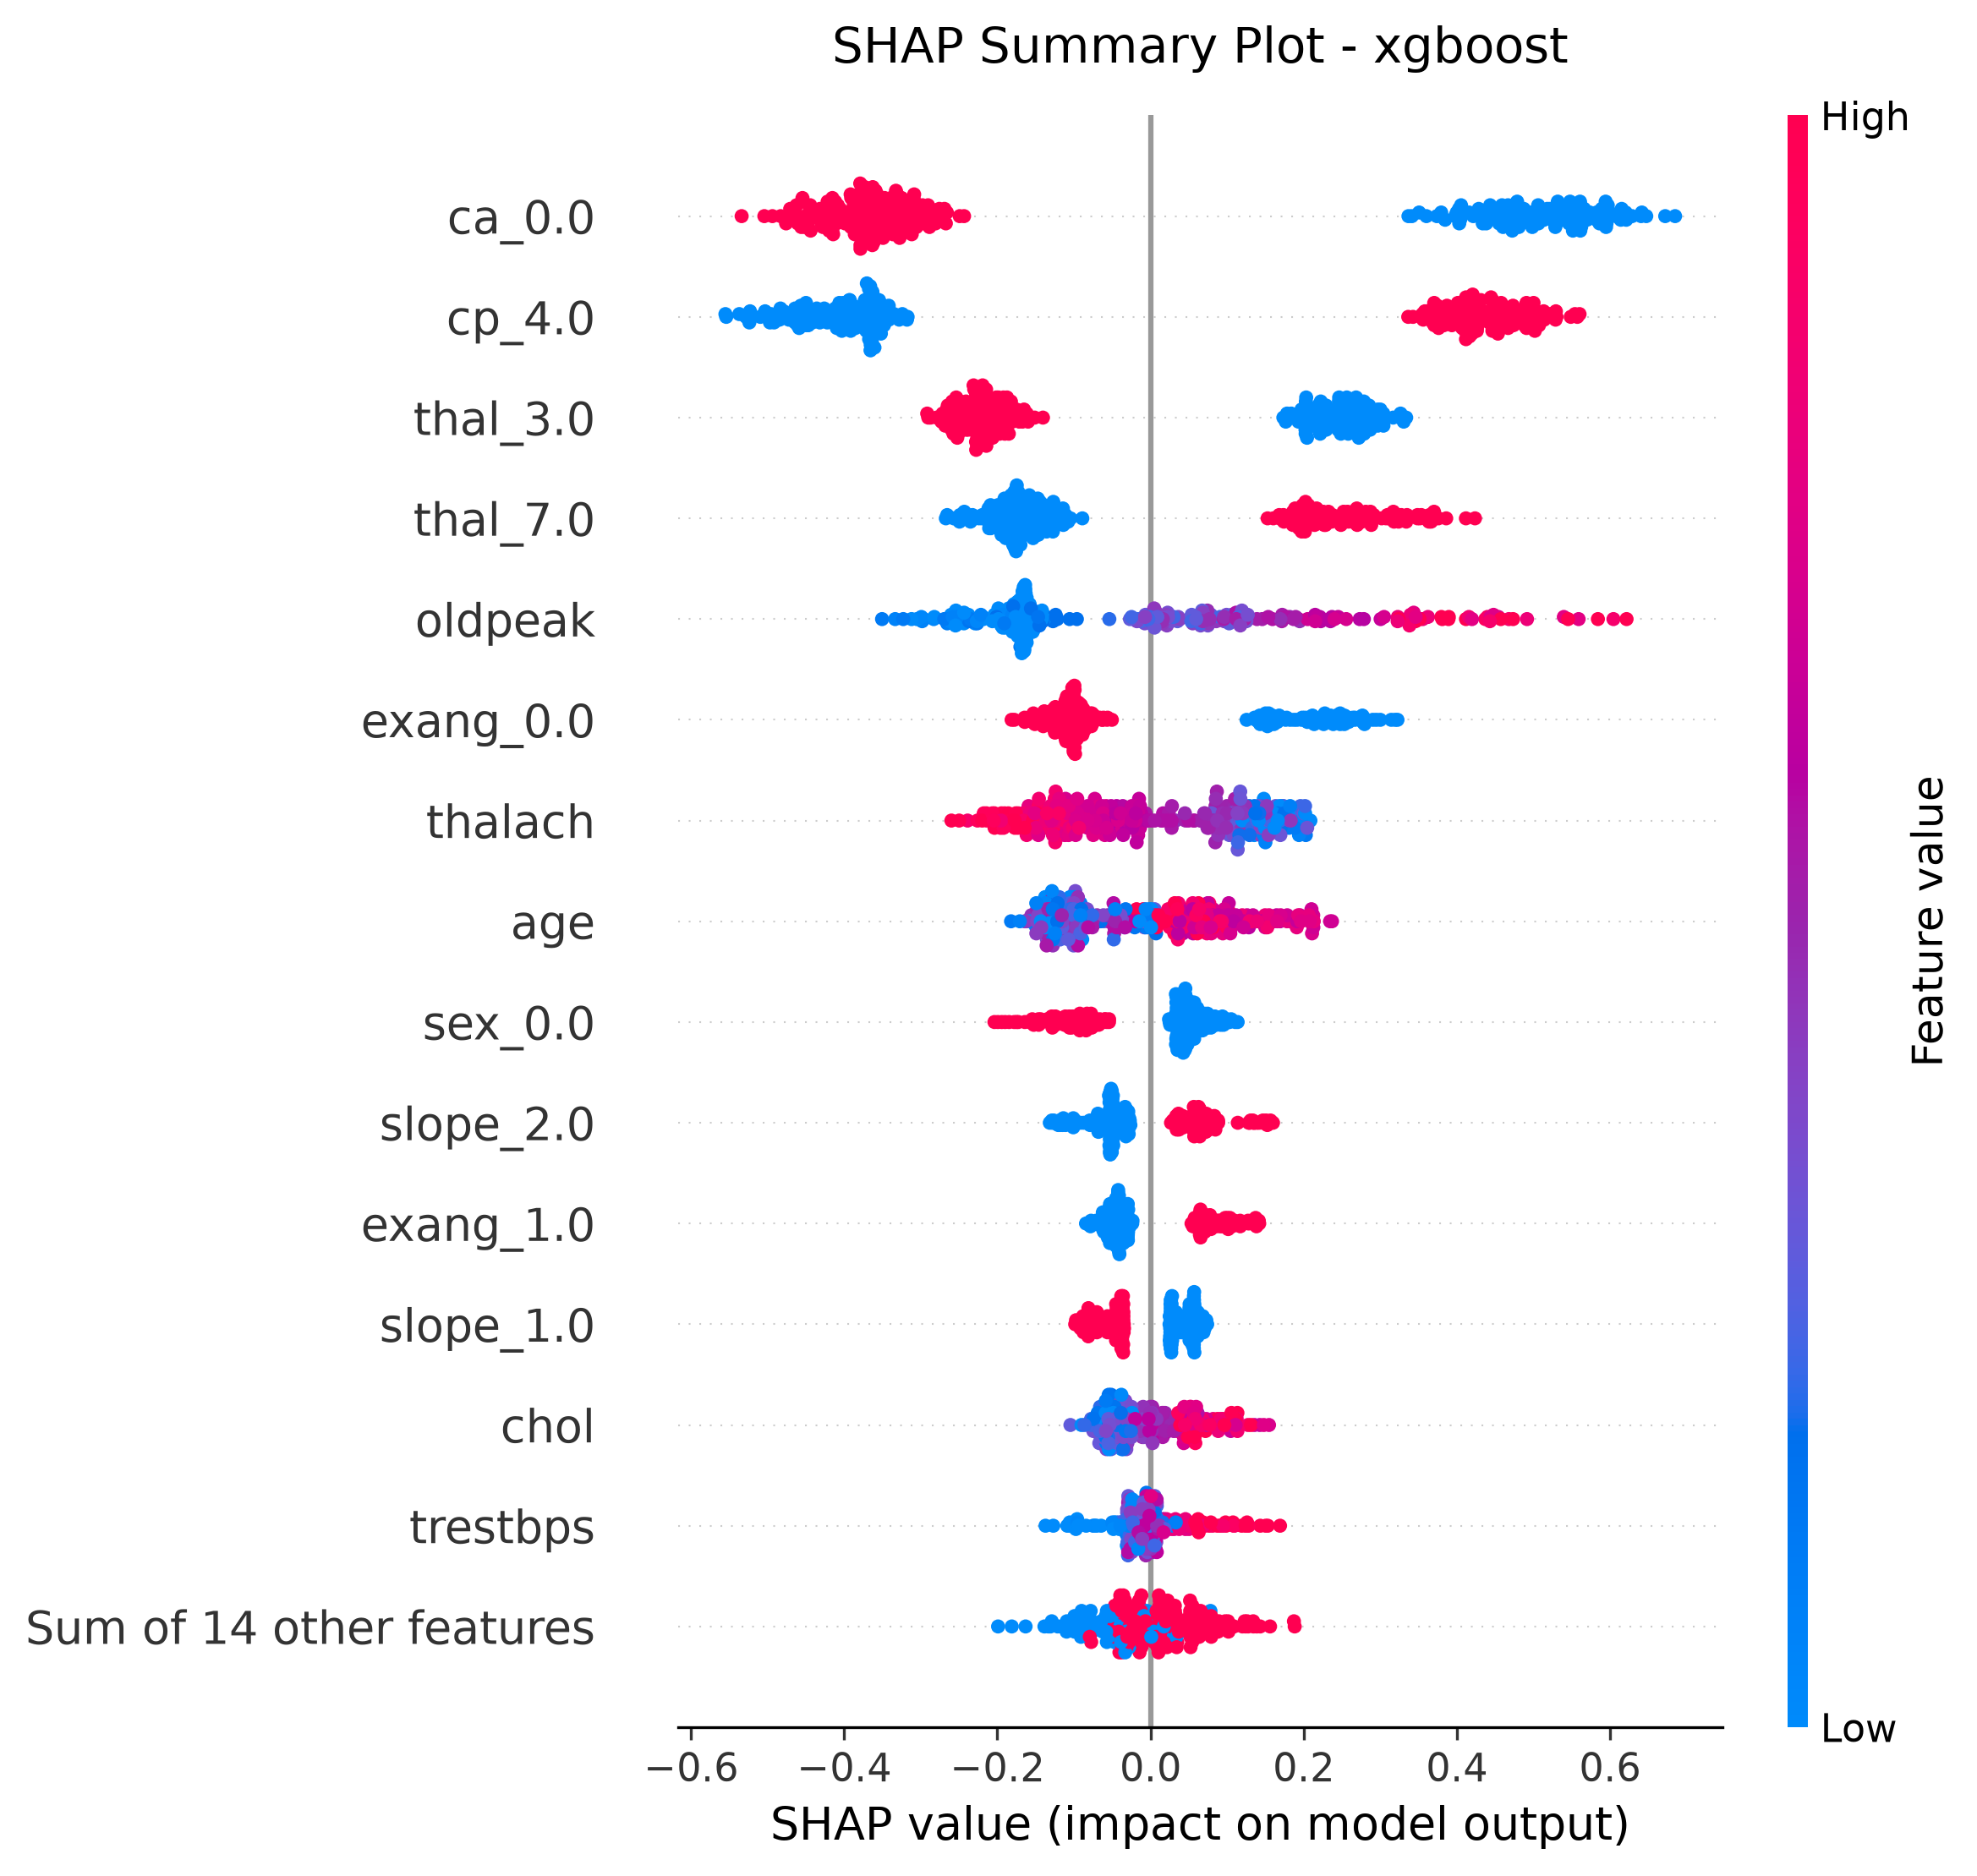

--- SHAP Feature Importance Bar Plot ---


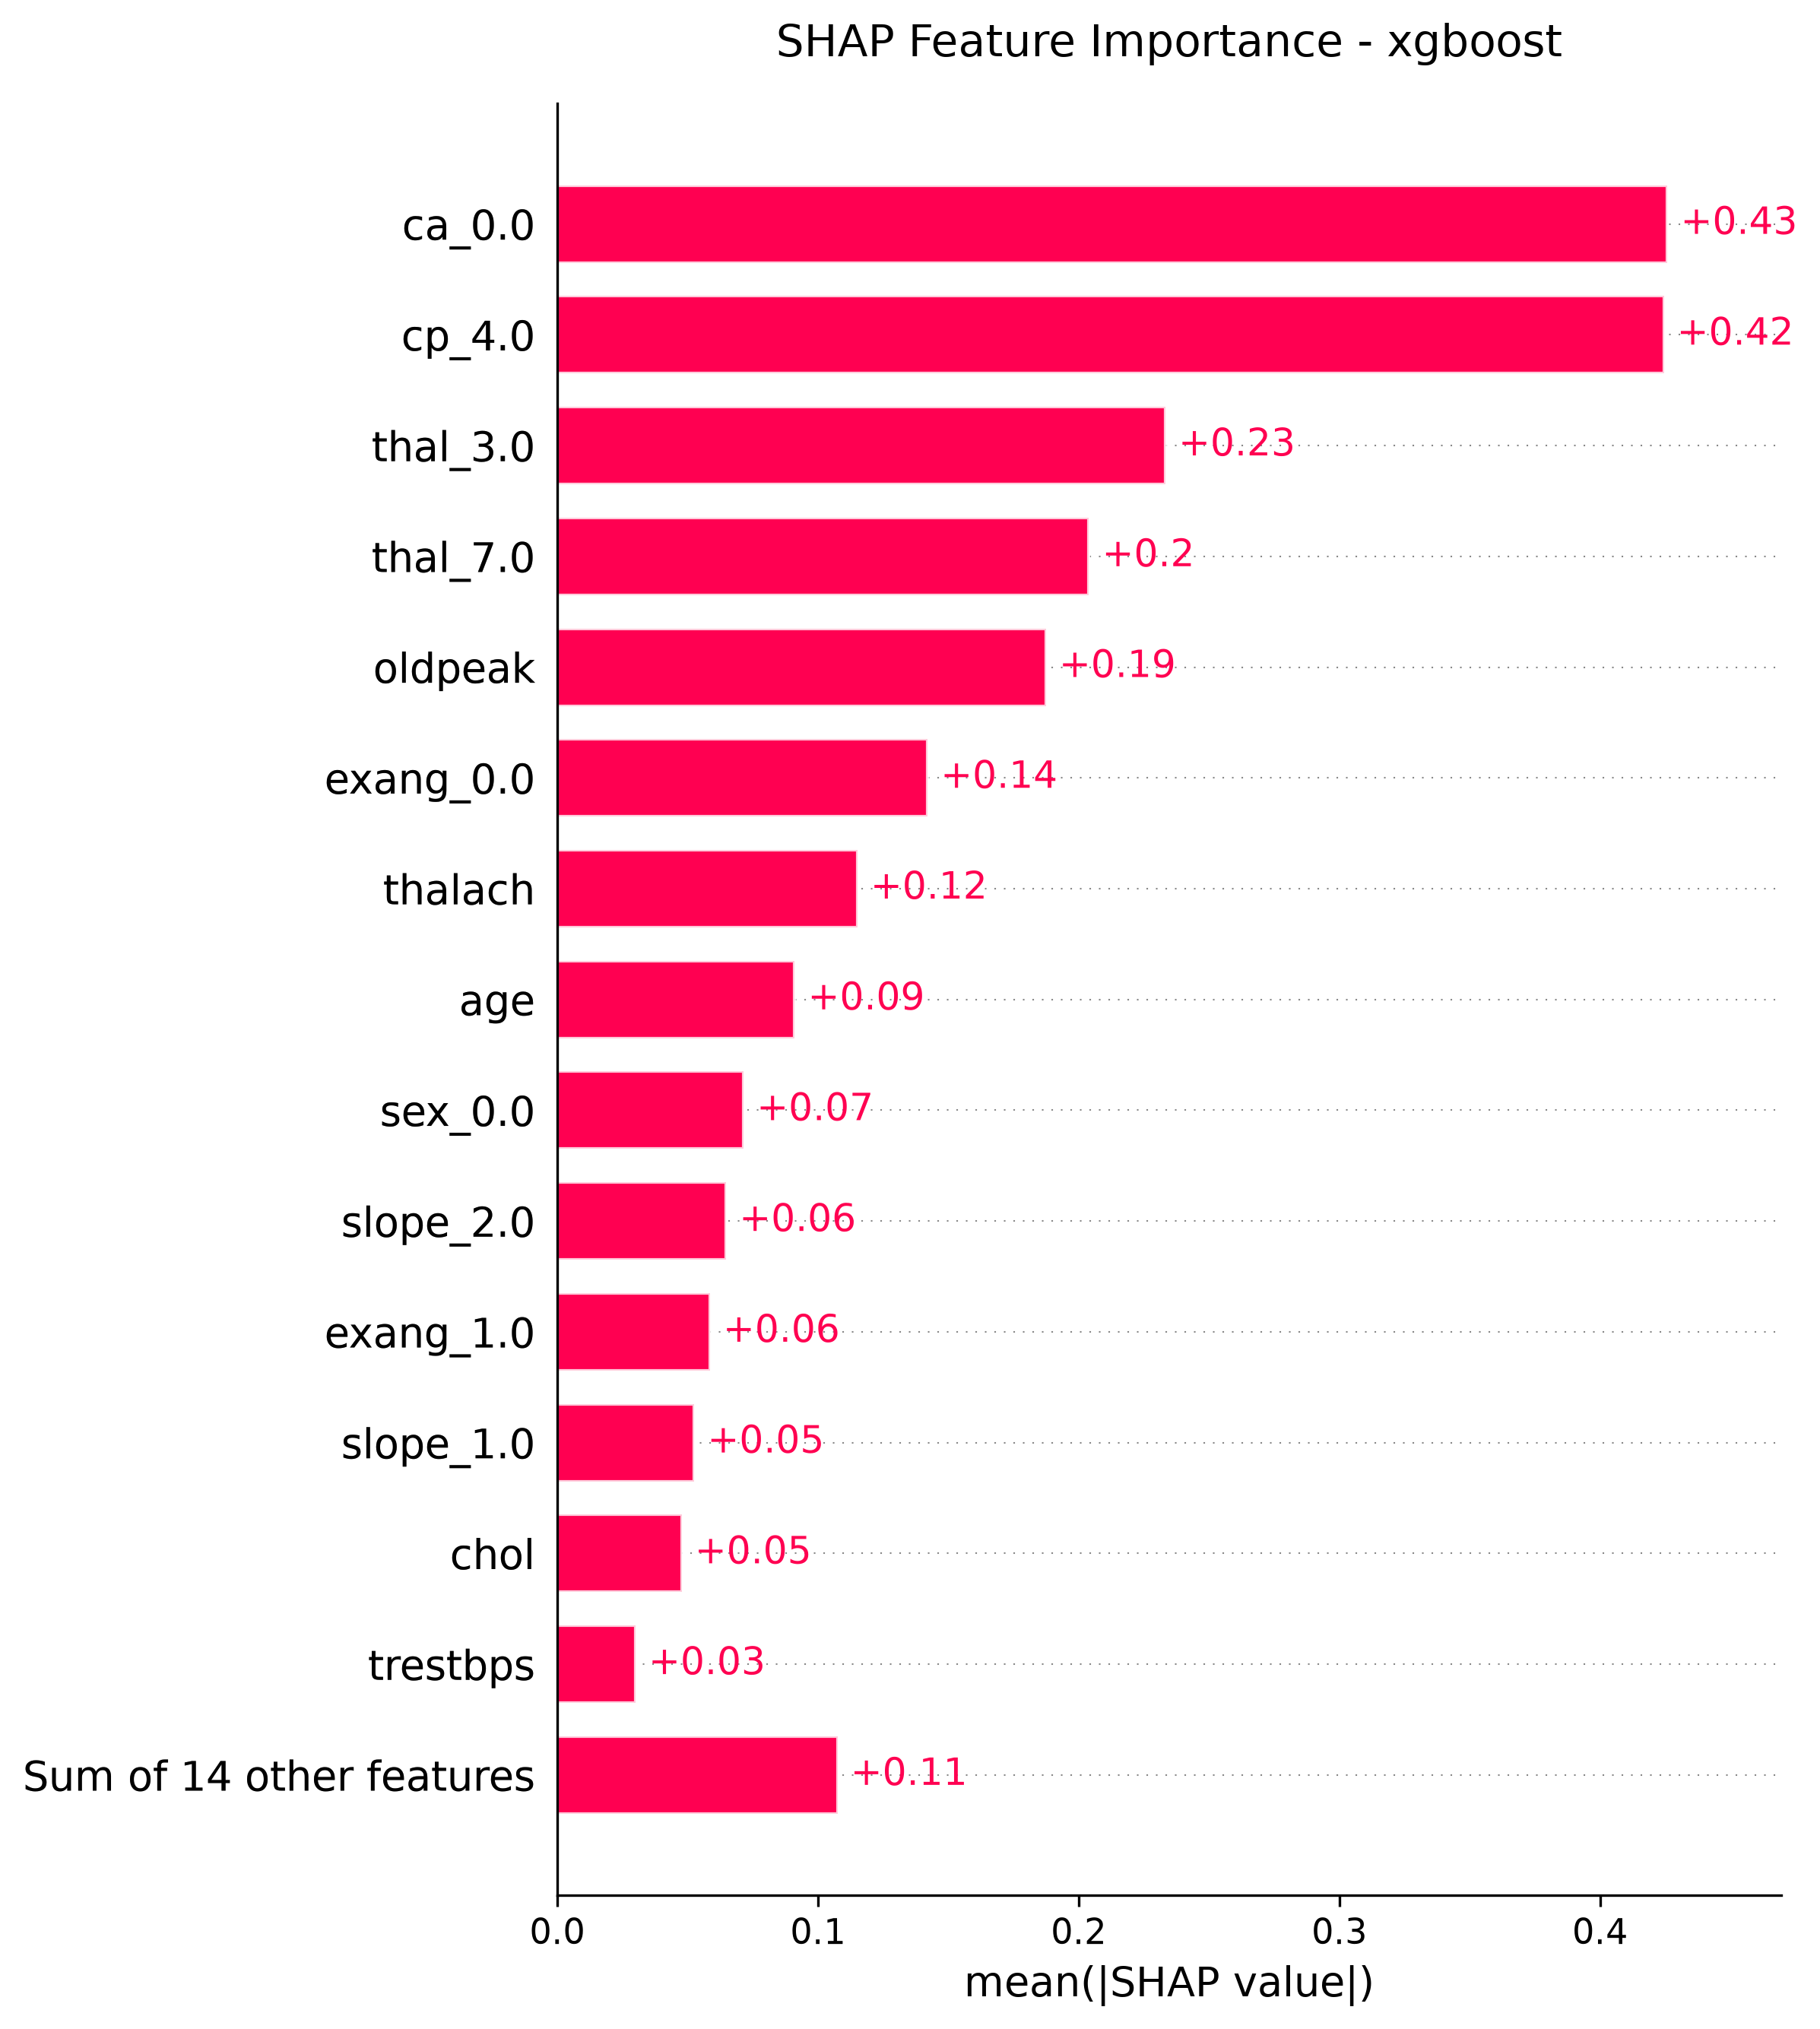

--- SHAP Sample 0 Waterfall Plot ---


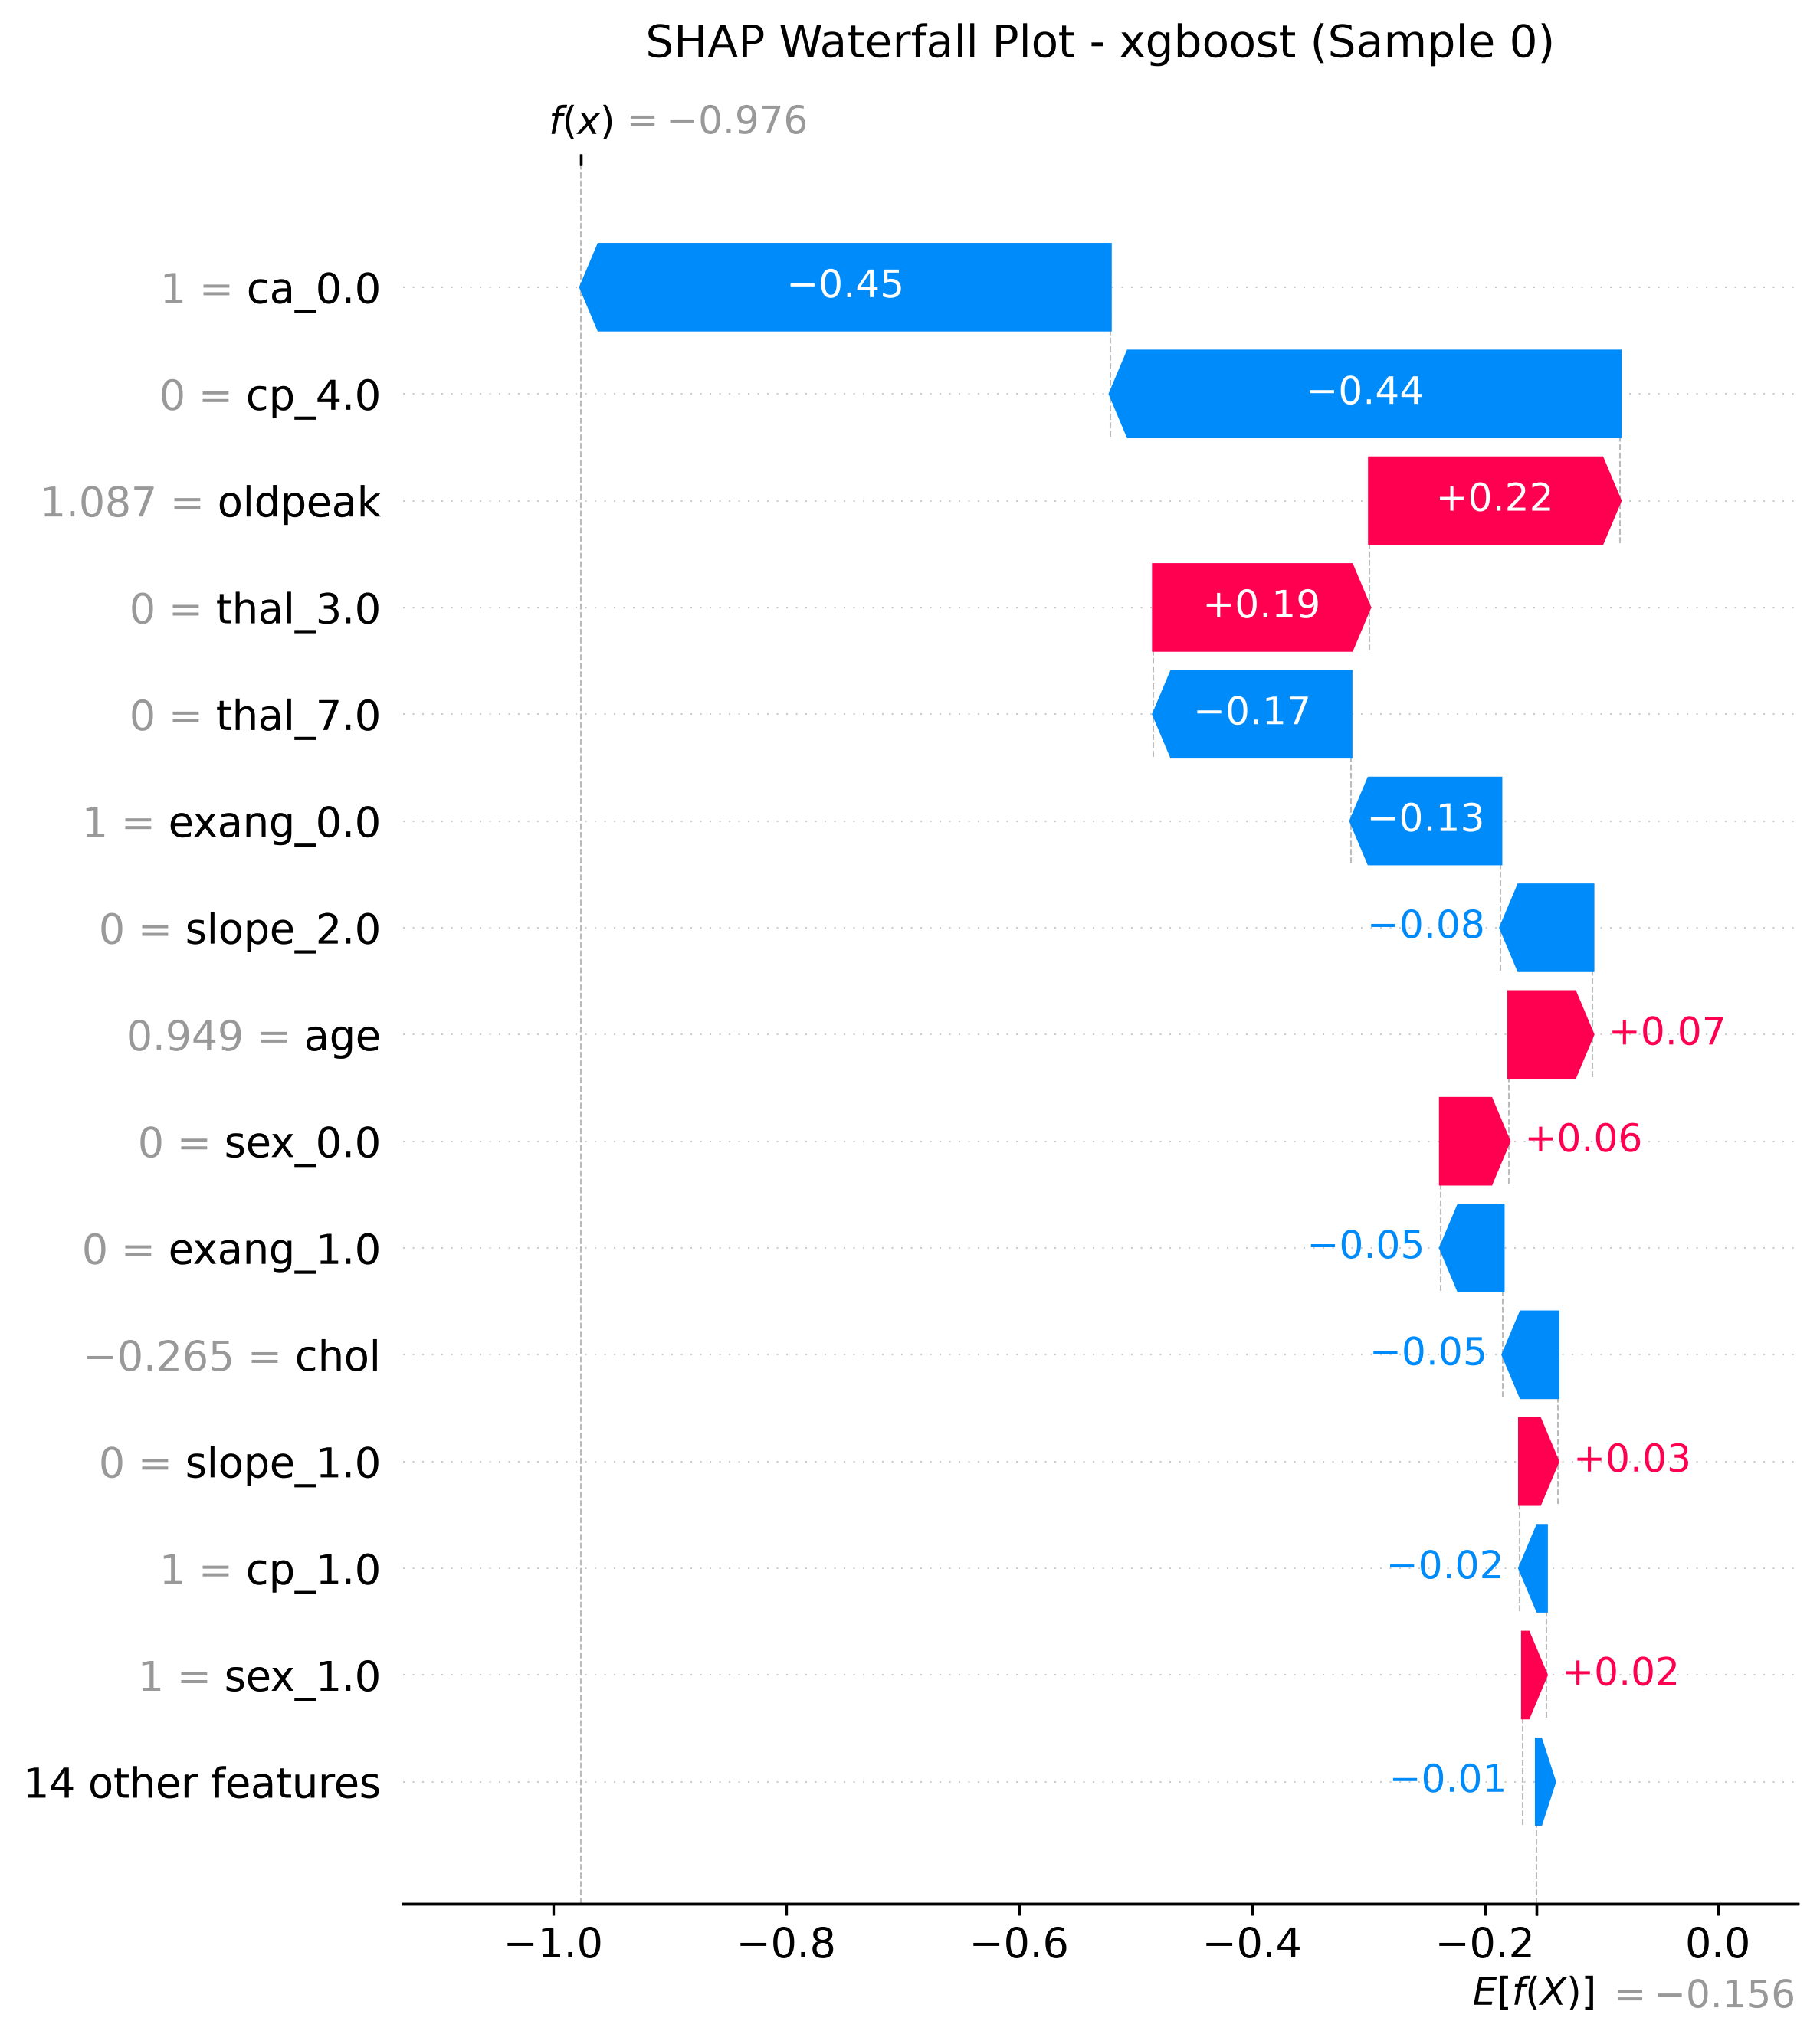

In [8]:
from IPython.display import Image, display

print("--- SHAP Beeswarm Summary Plot ---")
display(Image(filename=f"{results_dir}/xgboost_shap_summary.png"))

print("--- SHAP Feature Importance Bar Plot ---")
display(Image(filename=f"{results_dir}/xgboost_shap_bar.png"))

print("--- SHAP Sample 0 Waterfall Plot ---")
display(Image(filename=f"{results_dir}/xgboost_shap_sample_0.png"))
